In [4]:
#import relevant libraries
import numpy as np
import seaborn as sns
import random
import math
import cmath
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from IPython.display import HTML
from collections import defaultdict

In [5]:
#function generates lattice of 1s and 0s; 1 means there's a firefly there, 0 means it's empty
def lattice(rows, cols, prop_one): #prop_one is proportion of ones
    tot_cells = rows * cols
    num_ones = int(tot_cells * prop_one)

    arr = np.zeros((rows, cols))

    ind_ones = np.random.choice(tot_cells, num_ones, replace = False)
    row_ind = ind_ones // cols
    col_ind = ind_ones % cols

    arr[row_ind, col_ind] = 1

    return arr

#function generates list of firefly phases between 0 and 2pi 
def phase_list(num_ff):
    phases = []
    while len(phases) < num_ff:
        phase = random.uniform(0, 2 * math.pi)
        if phase != 0 and phase != 2 * math.pi:
            phases.append(phase)
    return phases

#function assigns non-empty lattice positions to firefly phases from list
def phase_arr(positions, phases):
    phase_array = np.zeros_like(positions)
    occ_indices = np.argwhere(positions) #list of indices with non-zero entries

    count = 0

    for i, j in occ_indices:
        phase_array[i, j] = phases[count]
        count = count + 1
    return phase_array          

#function assigns -1 (cooperator) or -2 (defector) to all non-empty lattice positions based on specified proportion
def strat_arr(positions, propC):
    total_nonzero = np.count_nonzero(positions)
    num_coop = int(total_nonzero * propC)
    num_def = total_nonzero - num_coop
    
    strat_arr = np.zeros_like(positions)
    nonzero_indices = np.nonzero(positions)

    indices_coop = np.random.choice(range(total_nonzero), size = num_coop, replace = False)
    indices_coop.astype(np.int64)

    indices_def = np.random.choice(np.array([x for x in range(total_nonzero) if x not in indices_coop.tolist()]), size = num_def, replace = False)
    indices_def.astype(np.int64)
    
    strat_arr[nonzero_indices[0][indices_coop], nonzero_indices[1][indices_coop]] = -1
    strat_arr[nonzero_indices[0][indices_def], nonzero_indices[1][indices_def]] = -2

    return strat_arr

#alternate strat assigning function
def altstrat(positions, propC):
    num_nz = np.count_nonzero(positions)
    num_coop = int(num_nz * propC)
    num_def = num_nz - num_coop

    altstrat = np.zeros_like(positions)
    nz_indices = np.argwhere(positions)
    ord_pairs = [tuple(index) for index in nz_indices]

    indices_coop = np.random.choice(len(ord_pairs), size = num_coop, replace = False)
    loc_coop = [ord_pairs[index_coop] for index_coop in indices_coop]

    rem_pairs = [pair for pair in ord_pairs if pair not in loc_coop]
    indices_def = np.random.choice(len(rem_pairs), size = num_def, replace = False)
    loc_def = [rem_pairs[index_def] for index_def in indices_def]

    for i, j in loc_coop:
        altstrat[i, j] = -1
    
    for i, j in loc_def:
        altstrat[i, j] = -2
    
    return altstrat

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def coh(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/len(compexp_list)
    return phaseorder

#function gives list of phases of focal cell and its non-zero neighbors
def neighbors(a, radius, r, c):
    numlist = [ a[i, j] if  i >= 0 and i < len(a) and j >= 0 and j < len(a[0]) else 0
                for j in range(c - 1 - radius, c + radius)
                    for i in range(r - 1 - radius, r + radius) ]
    non_zero_nghbrs = [x for x in numlist if x != 0]
    return non_zero_nghbrs

def get_neighbors(arr, row, col):
    # Define the possible relative positions of the 8 neighbors
    neighbor_positions = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),         (0, 1),
        (1, -1), (1, 0), (1, 1)
    ]
    
    neighbors = []
    
    # Iterate through the possible neighbor positions
    for pos in neighbor_positions:
        new_row, new_col = row + pos[0], col + pos[1]
        
        # Check if the new position is within the bounds of the array
        if 0 <= new_row < arr.shape[0] and 0 <= new_col < arr.shape[1]:
            if arr[new_row, new_col] != 0:
                neighbors.append(arr[new_row, new_col])
    
    return neighbors

def pay1(ph_arr, st_arr, r, c):
    neighphase = get_neighbors(ph_arr, r, c)
    phasediffcos = [np.cos(ph_arr[r, c] - x) for x in neighphase]

    neighstrat = get_neighbors(st_arr, r, c)
    zippedlist = list(zip(neighphase, neighstrat))

    strat_dict = defaultdict(list)
    for fit, strat in zippedlist:
        strat_dict[strat].append(fit)
    meandifflist = [(sum(fit)/len(fit), strat) for strat, fit in strat_dict.items()]
    
    return meandifflist #divide by len fit to remove density dependence


#function generates payoff array
def payoff_arr(ph_arr, strat_arr, rang):
    pay = np.zeros_like(ph_arr)
    filled_indices = np.argwhere(ph_arr)

    for i, j in filled_indices:
        k = neighbors(ph_arr, rang, i + 1, j + 1)
        if strat_arr[i, j] == -1:
            pay[i, j] = coh(k)
        else:
            pay[i, j] = coh(k) + cost
    return pay

def pay2(ph_arr, strat_arr):
    stp = 3
    pay = np.zeros_like(ph_arr)
    filled_indices = np.argwhere(ph_arr)

    for i, j in filled_indices:
        lista = pay1(ph_arr, strat_arr, i, j)
        lista.sort(key = lambda x: x[1])
        if not lista:
            if strat_arr[i, j] == -1:
                pay[i, j] = 0
            elif strat_arr[i, j] == -2:
                pay[i, j] = cost
        elif len(lista) == 1 and lista[0][1] == -1:
            if strat_arr[i, j] == -1:
                pay[i, j] = (2 * stp * lista[0][0])
            elif strat_arr[i, j] == -2:
                pay[i, j] = cost + (stp * lista[0][0])
        elif len(lista) == 1 and lista[0][1] == -2:
            if strat_arr[i, j] == -1:
                pay[i, j] = (stp * lista[0][0])
            elif strat_arr[i, j] == -2:
                pay[i, j] = cost
        elif len(lista) == 2:
            if strat_arr[i, j] == -1:
                pay[i, j] = (stp * lista[0][0]) + (2 * stp * lista[1][0])
            elif strat_arr[i, j] == -2:
                pay[i, j] = cost + (stp * lista[1][0])
    return pay

#function simultaneously updates phases based on Kuramoto dynamics; coops track neighboring phases, defs don't
def krmt(ph_arr, strat_arr):
    new_arr = np.zeros_like(ph_arr)
    nz_indices = np.argwhere(ph_arr)

    for i, j in nz_indices:
        if strat_arr[i, j] == -1:
            ph_nhbrs = neighbors(ph_arr, 7, i + 1, j + 1)
            diff_sin = [np.sin(k - ph_arr[i, j]) for k in ph_nhbrs]
            ph_diff = sum(diff_sin)
            new_arr[i, j] = ph_arr[i, j] + ((w + (K * ph_diff)) * dt) #discretized using first-order Taylor expansion; time-step assumed to be 1
            new_arr[i, j] %= 2 * math.pi
        elif strat_arr[i, j] == -2:
            new_arr[i, j] = ph_arr[i, j] + (w * dt)
            new_arr[i, j] %= 2 * math.pi
        else:
            continue    
    return new_arr   

def kur(phase, strat):
    phasenext = np.zeros_like(phase)
    fireflylocs = np.argwhere(phase)
    for i, j in fireflylocs:
        if strat[i, j] == -2:
            phasenext[i, j] = (phase[i, j] + (w * dt)) % (2 * math.pi)
        elif strat[i, j] == -1:
            nehbrs = neighbors(phase, 1, i + 1, j + 1)
            if len(nehbrs) == 0:
                phasenext[i, j] = (phase[i, j] + (w * dt)) % (2 * math.pi)
            else:
                cont = sum([np.sin(nehbr - phase[i, j]) for nehbr in nehbrs])
                phasenext[i, j] = (phase[i, j] + ((w + (K * cont)) * dt)) % (2 * math.pi)
    return phasenext         

def kur3(phase, strat, r, K):
    phasenext = np.zeros_like(phase)
    fireflylocs = [(i, j) for i, j in np.argwhere(phase)]
    for i, j in fireflylocs:
        if strat[i, j] == -1:
            nehbrs = neighbors(phase, r, i + 1, j + 1)
            templist = [np.sin(nehbr - phase[i, j]) for nehbr in nehbrs]
            cont = sum(templist)/len(templist)
            phasenext[i, j] = (phase[i, j] + (K * cont)) % (2 * math.pi)
        else:
            phasenext[i, j] = phase[i, j]
    return phasenext

#function that takes an array and a particular position index (row and column) and returns the list of empty indices in Moore neighborhood
def emptyneigh(arr, row, col):
    draft1 = [(row - 1, col - 1), (row - 1, col), (row - 1, col + 1), (row, col - 1), (row, col + 1), (row + 1, col - 1), (row + 1, col), (row + 1, col + 1)]
    draft2 = [(x, y) for x, y in draft1 if 0 <= x < arr.shape[0] and 0 <= y < arr.shape[1]]
    finaldraft = [(x, y) for x, y in draft2 if arr[x, y] == 0]
    return finaldraft

#function updates position, and carries phase and strat to new position too
def mov(phase, strat, old_pay, new_pay, k):
    pay_diff = np.subtract(new_pay, old_pay)
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        random_num = np.random.rand()
        prob = (1 + math.tanh(k * pay_diff[i, j]))/2 #probability of staying in same location
        if prob < random_num:
            neigbors = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
            neigbors_inbound = [(x, y) for x, y in neigbors if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
            neigbors_empty = [(x, y) for x, y in neigbors_inbound if strat[x, y] == 0]
            if neigbors_empty:
                new_i, new_j = neigbors_empty[np.random.randint(len(neigbors_empty))]
                phase[new_i, new_j] = phase[i, j] #print phases before and after
                strat[new_i, new_j] = strat[i, j]
                phase[i, j] = 0
                strat[i, j] = 0
    return phase, strat 

#alternate movement function
def mov2(phase, strat, pay):
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        neig = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
        neig_inbound = [(x, y) for x, y in neig if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
        neig_empty = [(x, y) for x, y in neig_inbound if strat[x, y] == 0]
        if neig_empty:
            if strat[i, j] == -1:
                payloc = [(coh(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]), (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
            if strat[i, j] == -2:
                payloc = [(coh(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]) + cost, (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
    return phase, strat

#third movement function
def mov3(phase, strat):
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        neig = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
        neig_inbound = [(x, y) for x, y in neig if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
        neig_empty = [(x, y) for x, y in neig_inbound if strat[x, y] == 0]
        if neig_empty:
            if strat[i, j] == -1:
                payloc = [(coh(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]), (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                new_i, new_j = max_payloc[1]
                phase[new_i, new_j] = phase[i, j]
                strat[new_i, new_j] = strat[i, j]
                phase[i, j] = 0
                strat[i, j] = 0
            if strat[i, j] == -2:
                payloc = [(coh(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]) + cost, (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                new_i, new_j = max_payloc[1]
                phase[new_i, new_j] = phase[i, j]
                strat[new_i, new_j] = strat[i, j]
                phase[i, j] = 0
                strat[i, j] = 0
    return phase, strat


#custom histogram function
def histo(phase, strat):
    #sorted phase lists
    coop = np.sort(phase[strat == -1])
    defc = np.sort(phase[strat == -2])

    #number of observations
    num_coop = len(coop)
    num_defc = len(defc)

    #find interquartile range (IQR) of phase distribution
    Q1_C = np.percentile(coop, 25)
    Q3_C = np.percentile(coop, 75)
    IQR_C = Q3_C - Q1_C
    #FD binning
    binw_C = (2 * IQR_C) / (num_coop ** (1. / 3))
    numbin_C = int((coop[-1] - coop[0]) / binw_C)

    Q1_D = np.percentile(defc, 25)
    Q3_D = np.percentile(defc, 75)
    IQR_D = Q3_D - Q1_D
    #FD binning
    binw_D = (2 * IQR_D) / (num_defc ** (1. / 3))
    numbin_D = int((defc[-1] - defc[0]) / binw_D)

    numbin = max(numbin_C, numbin_D)

    plt.hist([coop, defc], bins = numbin, label = ['cooperators','defectors'], stacked = True)
    plt.show


#function that plots stacked histogram of phase distibution given phase and strategy arrays        
def dist(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))
    bins = np.linspace(1e-10, 2 * np.pi, 50)

    lalalist1 = []
    lalalist2 = []

    for i, (phase, strat) in enumerate(numlist):
        coop = phase[strat == -1].tolist()
        defc = phase[strat == -2].tolist()

        lalalist1.append(defc)

        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]

        ax.hist([coop, defc], bins = bins, stacked = True, label = ['coop', 'def'])
        lalalist2.append(defc)

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()

    return lalalist1, lalalist2

#function that measures clustering coefficient (average neighborhood density) of fireflies
def clust_coeff(pos_array):
    numlist = []
    for i in range(len(pos_array)):
        for j in range(len(pos_array[0])):
            if pos_array[i, j] == 1:
                neigh = neighbors(pos_array, 1, i + 1, j + 1)
                density = (len(neigh) - 1)/8
                numlist.append(density)
            else:
                continue
    value = sum(numlist)/len(numlist)
    return value

#function that calculates strategy independent spatial statistics of the phase array
def spatstat(phase):
    filled_indices = np.argwhere(phase != 0)
    im_func = 0
    im_count = 0
    nn_func = 0
    nn_count = 0
    edgecorr = 1
    for i, j in filled_indices:
        for p, q in filled_indices:
            testfunc = abs(phase[i, j] - phase[p, q]) #difference of phases is quantity of interest
            sqdist = ((i - p) ** 2) + ((j - q) ** 2)
            if sqdist == 1 or sqdist == 2: #if one filled index is in the immediate neighborhood of the other
                im_count += 1
                im_func += (testfunc * edgecorr)
            elif sqdist == 2 or sqdist == 5 or sqdist == 8: #if one filled index is in the next nearest neighborhood of the other
                nn_count += 1
                nn_func += (testfunc * edgecorr)

    im_val = im_func/im_count
    nn_val = nn_func/nn_count 
    return im_val, nn_val


#function that chooses (based on payoff values) a single male for mating
def mate_choice(payoff_array, strat_array):
    non_zero_sum = np.sum(payoff_array[payoff_array != 0]) #sum of payoffs
    mateprob_array = payoff_array / non_zero_sum #normalized fitness payoff, equal to mating probability

    non_zero_indices = np.transpose(np.nonzero(mateprob_array)) #indices of fireflies
    non_zero_values = mateprob_array[mateprob_array.nonzero()] #probabilities

    chosen_index = np.random.choice(len(non_zero_values), p = non_zero_values) #making random weighted choice
    chosen_indices = non_zero_indices[chosen_index] #index of chosen male

    chosen_strat = strat_array[chosen_indices[0], chosen_indices[1]] #strategy of chosen male

    return chosen_strat

#display heatmap of phases, with red gradient for cooperators and blue gradient for defectors
def disp_phase_and_strat(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))

    cmap_red = plt.cm.get_cmap('Reds')
    norm_red = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    cmap_blue = plt.cm.get_cmap('Blues')
    norm_blue = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    for i, (phase, strat) in enumerate(numlist):
        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]
        
        masked_phase_red = np.ma.masked_where(strat != -1, phase)
        masked_phase_blue = np.ma.masked_where(strat != -2, phase)

        ax.imshow(masked_phase_red, cmap = cmap_red, norm = norm_red, interpolation = 'nearest')
        ax.imshow(masked_phase_blue, cmap = cmap_blue, norm = norm_blue, interpolation = 'nearest')
        ax.set_title(f'Plot {i+1}')

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4, wspace = 0.4)
    plt.show()    

#display mated_stratlist proportions in a pie chart
def piechart(numlist):
    counts = {val: numlist.count(val) for val in set(numlist)}
    
    labels = ['coop', 'def']
    sizes = [counts.get(-1, 0), counts.get(-2, 0)]
    colors = ['red', 'blue']

    plt.pie(sizes, labels = labels, colors = colors)
    plt.axis('equal')
    
    plt.show(block = False)
    plt.pause(0.001)

#find proportion of cooperators for next generation from matedstratlist of previous generation
def nextprop(prevlist):
    numcoop = prevlist.count(-1.0)
    propcoop = numcoop / len(prevlist)
    return propcoop



In [ ]:
#iterating over many generations
gen = 200
nights_per_gen = 30
repeats_per_night = 200

#initialize things that will stay same for all generations
rootN = 20 #size of location array
filledprop = 0.5 #proportion of sites filled with fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
nf = int(nm / 2) #number of female fireflies

cost = 0.005 #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 3 #prob move steepness
rang = 1 #payoff determination range

matelist_3d = np.zeros((gen, nights_per_gen, nf))

for i in range(gen):
    #initialize things that change with every generation but stay fixed for a particular generation
    if i == 0:
        coopprop = 0.995
    else:
        matelist_2d = matelist_3d[i - 1, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
    
    for j in range(nights_per_gen):
        #initialize things that are different every night
        init_pos = lattice(rootN, rootN, filledprop)
        init_phase_list = phase_list(nm)
        init_phase = phase_arr(init_pos, init_phase_list)
        init_strat = strat_arr(init_pos, coopprop)
        init_pay = payoff_arr(init_phase, init_strat, rang)

        #fem_timepoints = np.random.choice(repeats_per_night, nf, replace = False)
        fem_timepoints = np.random.choice(np.arange(75, repeats_per_night), nf, replace=False) #picking only from saturated part of payoff curve
        fem_timepoints.sort()

        mate_count = 0

        for k in range(repeats_per_night):
            #mating
            if k in fem_timepoints:
                mate_strat = mate_choice(init_pay, init_strat)
                matelist_3d[i, j, mate_count] = mate_strat
                mate_count += 1

            #phase update
            next_phase = kur3(init_phase, init_strat, r, K)
            next_pay = payoff_arr(next_phase, init_strat, rang)

            #position update
            mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
            #mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
        
            init_phase = mov_phase
            init_strat = mov_strat
            init_pay = payoff_arr(init_phase, init_strat, rang)
                    

KeyboardInterrupt: 

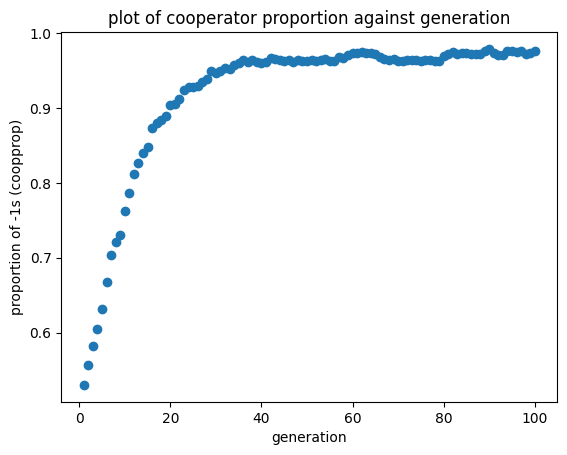

In [11]:
# Assuming matelist_3d is your 3D array and n is the range for i
n = matelist_3d.shape[0]  # Assuming i goes from 0 to n-1

# Initialize a list to store coopprop values
coopprop_values = []

# Loop over each index i
for i in range(n):
    matelist_2d = matelist_3d[i, :, :]
    num_coop = np.count_nonzero(matelist_2d == -1)
    tot = matelist_2d.size
    coopprop = num_coop / tot
    coopprop_values.append(coopprop)

# Create a scatter plot
plt.scatter(range(1,n+1), coopprop_values)
plt.xlabel('generation')
plt.ylabel('proportion of -1s (coopprop)')
plt.title('plot of cooperator proportion against generation')
plt.show()

In [33]:
#iterating over many generations
gen = 200
nights_per_gen = 30
repeats_per_night = 20000
payoff_saturation_timepoint = 75

#initialize things that will stay same for all generations
rootN = 20 #size of location array
filledprop = 0.5 #proportion of sites filled with fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
nf = int(nm / 2) #number of female fireflies

cost = 0.05 #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 3 #prob move steepness
rang = 1 #payoff determination range
start_cfreq = 0.995

matelist_3d = np.zeros((gen, nights_per_gen, nf))

for i in range(gen):
    #initialize things that change with every generation but stay fixed for a particular generation
    if i == 0:
        coopprop = start_cfreq
    else:
        matelist_2d = matelist_3d[i - 1, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
    
    for j in range(nights_per_gen):
        #initialize things that are different every night
        init_pos = lattice(rootN, rootN, filledprop)
        init_phase_list = phase_list(nm)
        init_phase = phase_arr(init_pos, init_phase_list)
        init_strat = strat_arr(init_pos, coopprop)
        init_pay = payoff_arr(init_phase, init_strat, rang)

        fem_timepoints = np.random.choice(repeats_per_night, nf, replace = False)
        #fem_timepoints = np.random.choice(np.arange(75, repeats_per_night), nf, replace=False) #picking only from saturated part of payoff curve
        fem_timepoints.sort()

        mate_count = 0

        for k in range(payoff_saturation_timepoint):
            #mating
            if k in fem_timepoints:
                mate_strat = mate_choice(init_pay, init_strat)
                matelist_3d[i, j, mate_count] = mate_strat
                mate_count += 1

            #phase update
            next_phase = kur3(init_phase, init_strat, r, K)
            next_pay = payoff_arr(next_phase, init_strat, rang)

            #position update
            mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
            #mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
        
            init_phase = mov_phase
            init_strat = mov_strat
            init_pay = payoff_arr(init_phase, init_strat, rang)
                    
        for k in range(payoff_saturation_timepoint, repeats_per_night):
            #mating
            if k in fem_timepoints:
                mate_strat = mate_choice(init_pay, init_strat)
                matelist_3d[i, j, mate_count] = mate_strat
                mate_count += 1
            #no phase or position updates

print(mate_count)

100


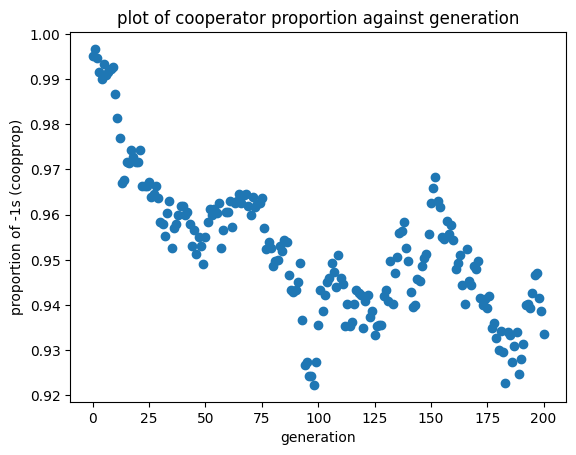

Equilibrium proportion: 0.9380
Asymptote time (generation): 198


In [34]:
# Assuming matelist_3d is your 3D array and n is the range for i
n = matelist_3d.shape[0]  # Assuming i goes from 0 to n-1

# Initialize a list to store coopprop values
coopprop_values = []

# Loop over each index i
for i in range(n):
    matelist_2d = matelist_3d[i, :, :]
    num_coop = np.count_nonzero(matelist_2d == -1)
    tot = matelist_2d.size
    coopprop = num_coop / tot
    coopprop_values.append(coopprop)
    
# Create a scatter plot
coopprop_values.insert(0, start_cfreq)
plt.scatter(range(n+1), coopprop_values)
plt.xlabel('generation')
plt.ylabel('proportion of -1s (coopprop)')
plt.title('plot of cooperator proportion against generation')
plt.show()

coopprop_values = np.array(coopprop_values)

def moving_average(data, window_size):
    """Simple moving average"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Find asymptote time: first index where moving average stays within tolerance till end
def find_asymptote(ma, equilibrium, tol):
    for i in range(len(ma)):
        # check if all subsequent points stay within tolerance band
        if np.all(np.abs(ma[i:] - equilibrium) <= tol):
            return i + (window_size // 2)  # adjust for convolution offset
    return None

window_size = 3
tolerance = 0.005

ma = moving_average(coopprop_values, window_size)
equilibrium = ma[-1]

asymptote_time = find_asymptote(ma, equilibrium, tolerance)
print(f"Equilibrium proportion: {equilibrium:.4f}")
print(f"Asymptote time (generation): {asymptote_time}")

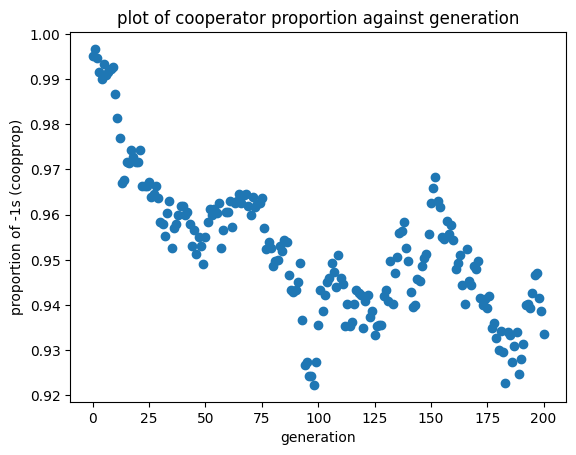

Asymptote (flat trend) detected at generation: 33


In [35]:
# Assuming matelist_3d is your 3D array and n is the range for i
n = matelist_3d.shape[0]  # Assuming i goes from 0 to n-1

# Initialize a list to store coopprop values
coopprop_values = []

# Loop over each index i
for i in range(n):
    matelist_2d = matelist_3d[i, :, :]
    num_coop = np.count_nonzero(matelist_2d == -1)
    tot = matelist_2d.size
    coopprop = num_coop / tot
    coopprop_values.append(coopprop)
    
# Create a scatter plot
coopprop_values.insert(0, start_cfreq)
plt.scatter(range(n+1), coopprop_values)
plt.xlabel('generation')
plt.ylabel('proportion of -1s (coopprop)')
plt.title('plot of cooperator proportion against generation')
plt.show()

coopprop_values = np.array(coopprop_values)

def detect_equilibrium_flat(data, eps, min_steps):
    diffs = np.abs(np.diff(data))
    for i in range(len(diffs) - min_steps):
        if np.all(diffs[i:i+min_steps] < eps):
            return i + min_steps
    return None

asymptote_time = detect_equilibrium_flat(coopprop_values, eps=0.01, min_steps=20)
print(f"Asymptote (flat trend) detected at generation: {asymptote_time}")

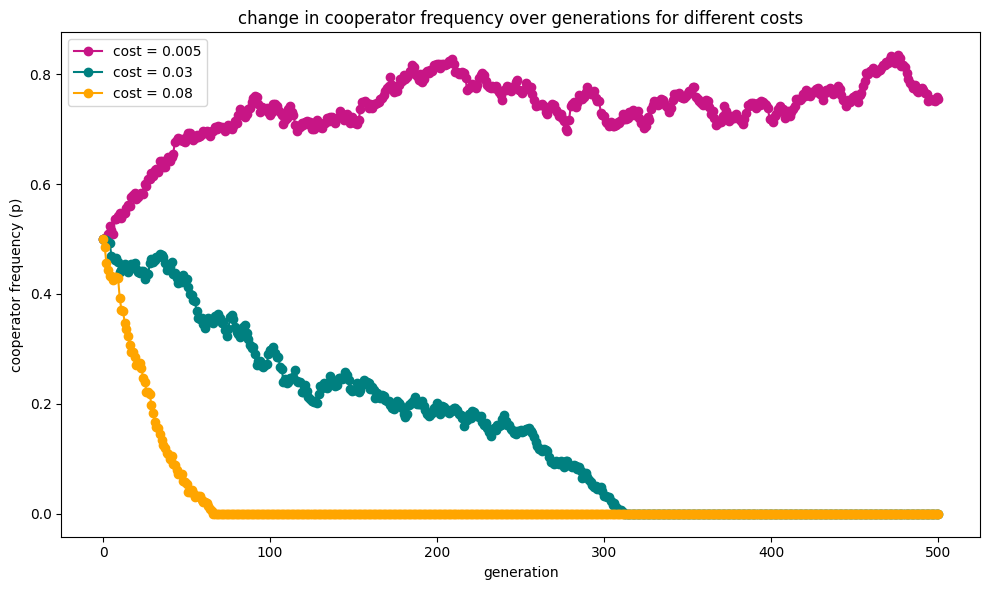

In [7]:
gen = 500
nights_per_gen = 30
repeats_per_night = 10000
payoff_saturation_timepoint = 75
rootN = 20
filledprop = 0.5
nm = int((rootN ** 2) * filledprop)
nf = int(nm / 2)
r = 1
K = 0.5
k = 3
rang = 1
start_cfreq = 0.5

cost_values = [0.005, 0.03, 0.08]
colors = ['mediumvioletred', 'teal', 'orange']

plt.figure(figsize=(10, 6))

for idx, cost in enumerate(cost_values):
    coopprop_values = [start_cfreq]
    matelist_3d = np.zeros((gen, nights_per_gen, nf))
    
    for i in range(gen):
        # Update coopprop based on previous gen
        if i == 0:
            coopprop = start_cfreq
        else:
            matelist_2d = matelist_3d[i - 1, :, :]
            num_coop = np.count_nonzero(matelist_2d == -1)
            coopprop = num_coop / matelist_2d.size

        for j in range(nights_per_gen):
            init_pos = lattice(rootN, rootN, filledprop)
            init_phase_list = phase_list(nm)
            init_phase = phase_arr(init_pos, init_phase_list)
            init_strat = strat_arr(init_pos, coopprop)
            init_pay = payoff_arr(init_phase, init_strat, rang)

            fem_timepoints = np.random.choice(repeats_per_night, nf, replace=False)
            fem_timepoints.sort()
            mate_count = 0

            for t in range(payoff_saturation_timepoint):
                if t in fem_timepoints:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1

                next_phase = kur3(init_phase, init_strat, r, K)
                next_pay = payoff_arr(next_phase, init_strat, rang)
                #mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
                mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
                init_phase, init_strat = mov_phase, mov_strat
                init_pay = payoff_arr(init_phase, init_strat, rang)

            for t in range(payoff_saturation_timepoint, repeats_per_night):
                if t in fem_timepoints:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1

    # Compute final coopprop time series
    for i in range(gen):
        matelist_2d = matelist_3d[i, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        coopprop = num_coop / matelist_2d.size
        coopprop_values.append(coopprop)

    # Plot this cost’s result
    plt.plot(range(gen + 1), coopprop_values, marker='o', linestyle='-',
             color=colors[idx], label=f'cost = {cost}')

# Plot formatting
plt.xlabel('generation')
plt.ylabel('cooperator frequency (p)')
plt.title('change in cooperator frequency over generations for different costs')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


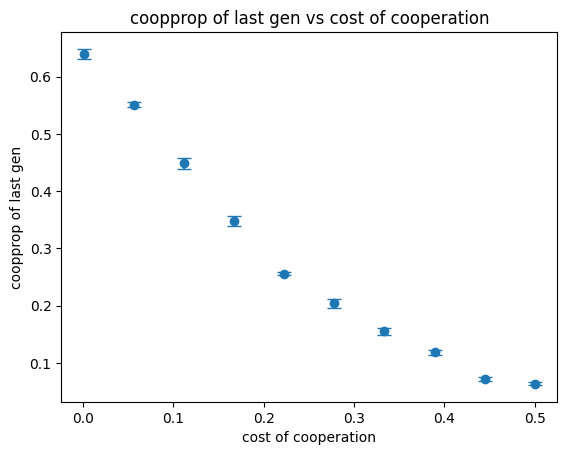

In [4]:
#plot to get variation of evolution with cost, movement rule 1
gen = 5
nights_per_gen = 30
repeats_per_night = 200

rootN = 20 #size of location array
filledprop = 0.5 #proportion of sites filled with fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
nf = int(nm / 2) #number of female fireflies

#cost = 0.5 #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 3 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
cost_values = np.linspace(0.001, 0.5, 10)  # range of costs
num_trials = 5  # number of trials for each cost

# Arrays to store results
mean_final_coopprop = []
std_error_final_coopprop = []

for cost in cost_values:
    final_coopprop_per_cost = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):

        matelist_3d = np.zeros((gen, nights_per_gen, nf))
        
        for i in range(gen):
            #initialize things that change with every generation but stay fixed for a particular generation
            if i == 0:
                coopprop = 0.5
            else:
                matelist_2d = matelist_3d[i - 1, :, :]
                num_coop = np.count_nonzero(matelist_2d == -1)
                tot = matelist_2d.size
                coopprop = num_coop / tot
    
            for j in range(nights_per_gen):
                #initialize things that are different every night
                init_pos = lattice(rootN, rootN, filledprop)
                init_phase_list = phase_list(nm)
                init_phase = phase_arr(init_pos, init_phase_list)
                init_strat = strat_arr(init_pos, coopprop)
                init_pay = payoff_arr(init_phase, init_strat, rang)

                fem_timepoints = np.random.choice(repeats_per_night, nf, replace = False)
                fem_timepoints.sort()

                mate_count = 0

                for k in range(repeats_per_night):
                    #mating
                    if k in fem_timepoints:
                        mate_strat = mate_choice(init_pay, init_strat)
                        matelist_3d[i, j, mate_count] = mate_strat
                        mate_count += 1

                    #phase update
                    next_phase = kur3(init_phase, init_strat, r, K)
                    next_pay = payoff_arr(next_phase, init_strat, rang)

                    #position update
                    mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
        
                    init_phase = mov_phase
                    init_strat = mov_strat
                    init_pay = payoff_arr(init_phase, init_strat, rang)

            
        matelist_2d = matelist_3d[-1, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
        final_coopprop_per_cost.append(coopprop)

    mean_final_cp = np.mean(final_coopprop_per_cost)
    std_error_final_cp = np.std(final_coopprop_per_cost) / np.sqrt(num_trials)

    # Store the results
    mean_final_coopprop.append(mean_final_cp)
    std_error_final_coopprop.append(std_error_final_cp)

# Plot variation of final standard deviation with cost including error bars
plt.errorbar(cost_values, mean_final_coopprop, yerr=std_error_final_coopprop, fmt='o', capsize=5)
plt.xlabel('cost of cooperation')
plt.ylabel('coopprop of last gen')
plt.title('coopprop of last gen vs cost of cooperation')
plt.show()

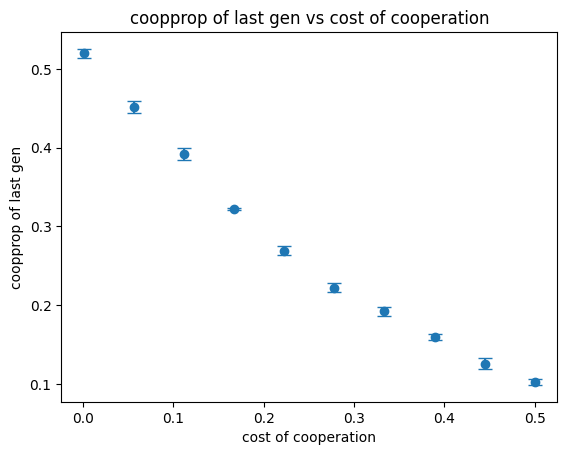

In [5]:
#plot to get variation of evolution with cost, movement rule 2
gen = 5
nights_per_gen = 30
repeats_per_night = 200

rootN = 20 #size of location array
filledprop = 0.5 #proportion of sites filled with fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
nf = int(nm / 2) #number of female fireflies

#cost = 0.5 #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 3 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
cost_values = np.linspace(0.001, 0.5, 10)  # range of costs
num_trials = 5  # number of trials for each cost

# Arrays to store results
mean_final_coopprop = []
std_error_final_coopprop = []

for cost in cost_values:
    final_coopprop_per_cost = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):

        matelist_3d = np.zeros((gen, nights_per_gen, nf))
        
        for i in range(gen):
            #initialize things that change with every generation but stay fixed for a particular generation
            if i == 0:
                coopprop = 0.5
            else:
                matelist_2d = matelist_3d[i - 1, :, :]
                num_coop = np.count_nonzero(matelist_2d == -1)
                tot = matelist_2d.size
                coopprop = num_coop / tot
    
            for j in range(nights_per_gen):
                #initialize things that are different every night
                init_pos = lattice(rootN, rootN, filledprop)
                init_phase_list = phase_list(nm)
                init_phase = phase_arr(init_pos, init_phase_list)
                init_strat = strat_arr(init_pos, coopprop)
                init_pay = payoff_arr(init_phase, init_strat, rang)

                fem_timepoints = np.random.choice(repeats_per_night, nf, replace = False)
                fem_timepoints.sort()

                mate_count = 0

                for k in range(repeats_per_night):
                    #mating
                    if k in fem_timepoints:
                        mate_strat = mate_choice(init_pay, init_strat)
                        matelist_3d[i, j, mate_count] = mate_strat
                        mate_count += 1

                    #phase update
                    next_phase = kur3(init_phase, init_strat, r, K)
                    next_pay = payoff_arr(next_phase, init_strat, rang)

                    #position update
                    mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
        
                    init_phase = mov_phase
                    init_strat = mov_strat
                    init_pay = payoff_arr(init_phase, init_strat, rang)

            
        matelist_2d = matelist_3d[-1, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
        final_coopprop_per_cost.append(coopprop)

    mean_final_cp = np.mean(final_coopprop_per_cost)
    std_error_final_cp = np.std(final_coopprop_per_cost) / np.sqrt(num_trials)

    # Store the results
    mean_final_coopprop.append(mean_final_cp)
    std_error_final_coopprop.append(std_error_final_cp)

# Plot variation of final standard deviation with cost including error bars
plt.errorbar(cost_values, mean_final_coopprop, yerr=std_error_final_coopprop, fmt='o', capsize=5)
plt.xlabel('cost of cooperation')
plt.ylabel('coopprop of last gen')
plt.title('coopprop of last gen vs cost of cooperation')
plt.show()

In [6]:
#plot to get variation of evolution with filledprop, movement rule 1
gen = 5
nights_per_gen = 30
repeats_per_night = 200

rootN = 20 #size of location array
cost = 0.1 #proportion of sites filled with fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
nf = int(nm / 2) #number of female fireflies

#cost = 0.5 #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 3 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
filledprops = np.linspace(0.05, 1, 10)  # range of costs
num_trials = 5  # number of trials for each cost

# Arrays to store results
mean_final_coopprop = []
std_error_final_coopprop = []

for filledprop in filledprops:
    final_coopprop_per_filledprop = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):

        matelist_3d = np.zeros((gen, nights_per_gen, nf))
        
        for i in range(gen):
            #initialize things that change with every generation but stay fixed for a particular generation
            if i == 0:
                coopprop = 0.5
            else:
                matelist_2d = matelist_3d[i - 1, :, :]
                num_coop = np.count_nonzero(matelist_2d == -1)
                tot = matelist_2d.size
                coopprop = num_coop / tot
    
            for j in range(nights_per_gen):
                #initialize things that are different every night
                init_pos = lattice(rootN, rootN, filledprop)
                init_phase_list = phase_list(nm)
                init_phase = phase_arr(init_pos, init_phase_list)
                init_strat = strat_arr(init_pos, coopprop)
                init_pay = payoff_arr(init_phase, init_strat, rang)

                fem_timepoints = np.random.choice(repeats_per_night, nf, replace = False)
                fem_timepoints.sort()

                mate_count = 0

                for k in range(repeats_per_night):
                    #mating
                    if k in fem_timepoints:
                        mate_strat = mate_choice(init_pay, init_strat)
                        matelist_3d[i, j, mate_count] = mate_strat
                        mate_count += 1

                    #phase update
                    next_phase = kur3(init_phase, init_strat, r, K)
                    next_pay = payoff_arr(next_phase, init_strat, rang)

                    #position update
                    mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
        
                    init_phase = mov_phase
                    init_strat = mov_strat
                    init_pay = payoff_arr(init_phase, init_strat, rang)

            
        matelist_2d = matelist_3d[-1, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
        final_coopprop_per_filledprop.append(coopprop)

    mean_final_fp = np.mean(final_coopprop_per_filledprop)
    std_error_final_fp = np.std(final_coopprop_per_filledprop) / np.sqrt(num_trials)

    # Store the results
    mean_final_coopprop.append(mean_final_fp)
    std_error_final_coopprop.append(std_error_final_fp)

# Plot variation of final standard deviation with cost including error bars
plt.errorbar(filledprops, mean_final_coopprop, yerr=std_error_final_coopprop, fmt='o', capsize=5)
plt.xlabel('filled proportion')
plt.ylabel('coopprop of last gen')
plt.title('coopprop of last gen vs filled proportion')
plt.show()

IndexError: list index out of range

In [20]:
def run_simulation(gen, nights_per_gen, repeats_per_night, payoff_saturation_timepoint,
                   rootN, filledprop, cost, r, K, k, rang, start_cfreq):
    
    nm = int((rootN ** 2) * filledprop)
    nf = int(nm / 2)
    matelist_3d = np.zeros((gen, nights_per_gen, nf))
    
    for i in range(gen):
        if i == 0:
            coopprop = start_cfreq
        else:
            matelist_2d = matelist_3d[i - 1, :, :]
            num_coop = np.count_nonzero(matelist_2d == -1)
            coopprop = num_coop / matelist_2d.size
        
        for j in range(nights_per_gen):
            init_pos = lattice(rootN, rootN, filledprop)
            init_phase_list = phase_list(nm)
            init_phase = phase_arr(init_pos, init_phase_list)
            init_strat = strat_arr(init_pos, coopprop)
            init_pay = payoff_arr(init_phase, init_strat, rang)

            fem_timepoints = np.random.choice(repeats_per_night, nf, replace=False)
            fem_timepoints.sort()
            mate_count = 0

            for k in range(payoff_saturation_timepoint):
                if k in fem_timepoints:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1

                next_phase = kur3(init_phase, init_strat, r, K)
                next_pay = payoff_arr(next_phase, init_strat, rang)
                #mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
                mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
                init_phase = mov_phase
                init_strat = mov_strat
                init_pay = payoff_arr(init_phase, init_strat, rang)

            for k in range(payoff_saturation_timepoint, repeats_per_night):
                if k in fem_timepoints:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1

    # Extract cooperator proportions
    coopprop_values = []
    for i in range(gen):
        matelist_2d = matelist_3d[i, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
        coopprop_values.append(coopprop)
    
    coopprop_values.insert(0, start_cfreq)
    return np.array(coopprop_values)


start_cfreq = 0.005, invasion probability = 0.00
start_cfreq = 0.010, invasion probability = 0.00
start_cfreq = 0.015, invasion probability = 0.20
start_cfreq = 0.020, invasion probability = 0.50
start_cfreq = 0.025, invasion probability = 0.80
start_cfreq = 0.030, invasion probability = 1.00
start_cfreq = 0.035, invasion probability = 0.90
start_cfreq = 0.040, invasion probability = 1.00
start_cfreq = 0.045, invasion probability = 1.00
start_cfreq = 0.050, invasion probability = 1.00


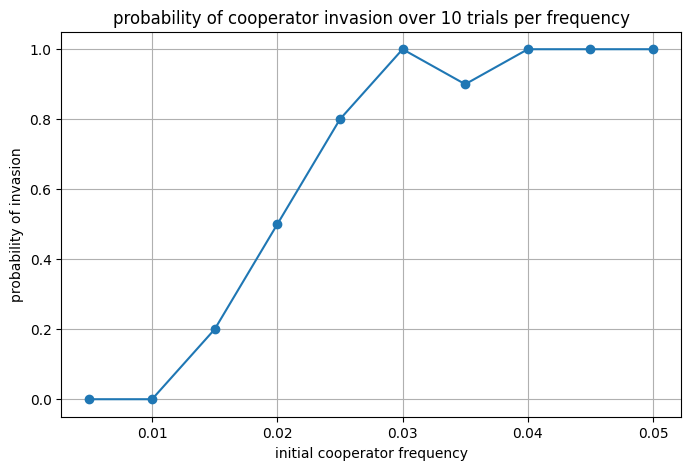

In [21]:
start_freqs = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
num_trials = 10
invasion_probs = []
cost = 0.005

for freq in start_freqs:
    success_count = 0
    for _ in range(num_trials):
        coopprops = run_simulation(
            gen = 10,
            nights_per_gen = 30,
            repeats_per_night = 10000,
            payoff_saturation_timepoint = 75,
            rootN = 20,
            filledprop = 0.5,
            cost = 0.005,
            r = 1,
            K = 0.5,
            k = 3,
            rang = 1,
            start_cfreq = freq
        )
        # Check if cooperation survived (i.e., not zero at the final gen)
        if coopprops[-1] > 0:
            success_count += 1
    invasion_probs.append(success_count / num_trials)
    print(f"start_cfreq = {freq:.3f}, invasion probability = {invasion_probs[-1]:.2f}")

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(start_freqs, invasion_probs, marker='o', linestyle='-')
plt.xlabel('initial cooperator frequency')
plt.ylabel('probability of invasion')
plt.title(f'probability of cooperator invasion over {num_trials} trials per frequency')
plt.grid(True)
plt.show()


start_cfreq = 0.995, invasion probability = 1.00
start_cfreq = 0.990, invasion probability = 1.00
start_cfreq = 0.985, invasion probability = 1.00
start_cfreq = 0.980, invasion probability = 1.00
start_cfreq = 0.975, invasion probability = 1.00
start_cfreq = 0.970, invasion probability = 1.00
start_cfreq = 0.965, invasion probability = 1.00
start_cfreq = 0.960, invasion probability = 1.00
start_cfreq = 0.955, invasion probability = 1.00
start_cfreq = 0.950, invasion probability = 1.00


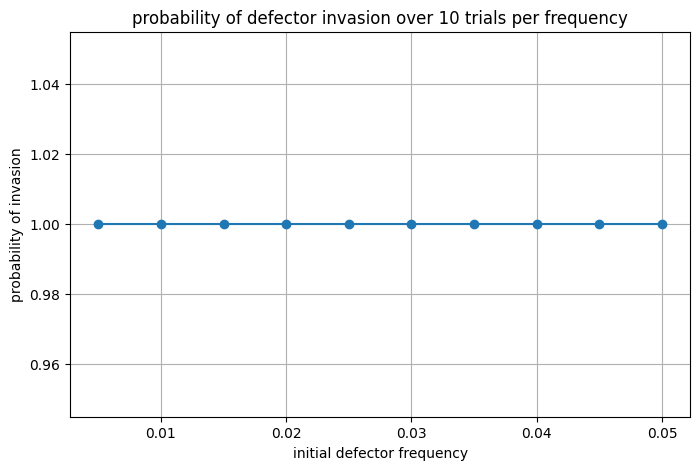

In [23]:
start_freqs = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
start_freqs = [1 - f for f in start_freqs]
num_trials = 10
invasion_probs = []
cost = 0.005

for freq in start_freqs:
    success_count = 0
    for _ in range(num_trials):
        coopprops = run_simulation(
            gen = 10,
            nights_per_gen = 30,
            repeats_per_night = 10000,
            payoff_saturation_timepoint = 75,
            rootN = 20,
            filledprop = 0.5,
            cost = 0.005,
            r = 1,
            K = 0.5,
            k = 3,
            rang = 1,
            start_cfreq = freq
        )
        # Check if defection survived (i.e., not zero at the final gen)
        if coopprops[-1] < 1:
            success_count += 1
    invasion_probs.append(success_count / num_trials)
    print(f"start_cfreq = {freq:.3f}, invasion probability = {invasion_probs[-1]:.2f}")

xaxis = [1 - f for f in start_freqs]
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(xaxis, invasion_probs, marker='o', linestyle='-')
plt.xlabel('initial defector frequency')
plt.ylabel('probability of invasion')
plt.title(f'probability of defector invasion over {num_trials} trials per frequency')
plt.grid(True)
plt.show()


In [28]:
num_trials = 20
all_trials = []

for _ in range(num_trials):
    coopprops = run_simulation(
        gen=10,
        nights_per_gen=30,
        repeats_per_night=20000,
        payoff_saturation_timepoint=75,
        rootN=20,
        filledprop=0.5,
        cost=0.05,
        r=1,
        K=0.5,
        k=3,
        rang=1,
        start_cfreq=0.5
    )
    all_trials.append(coopprops)

all_trials = np.array(all_trials)  # shape = (num_trials, gen + 1)


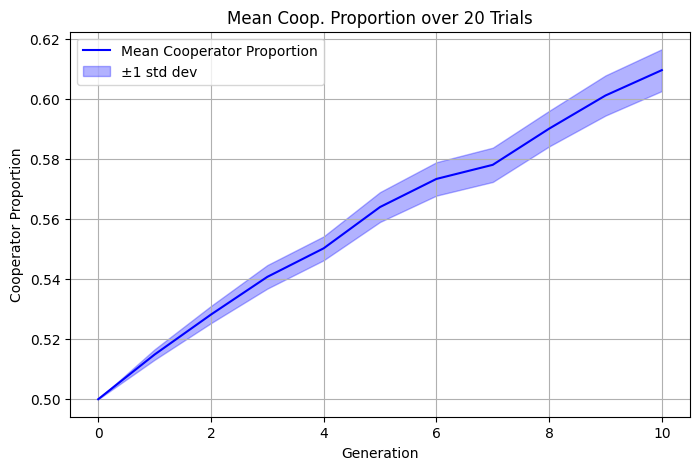

In [30]:
mean_vals = np.mean(all_trials, axis=0)
std_vals = np.std(all_trials, axis=0) / np.sqrt(num_trials)
gens = np.arange(len(mean_vals))

plt.figure(figsize=(8, 5))
plt.plot(gens, mean_vals, label='Mean Cooperator Proportion', color='blue')
plt.fill_between(gens, mean_vals - std_vals, mean_vals + std_vals, alpha=0.3, color='blue', label='±1 std dev')
plt.xlabel('Generation')
plt.ylabel('Cooperator Proportion')
plt.title(f'Mean Coop. Proportion over {num_trials} Trials')
plt.legend()
plt.grid(True)
plt.show()